# 规则置入置出分析 (rule_swap_analysis)

提供规则在生产模型评分体系上的置入/置出风险量化分析，支持：
- 四象限样本分布（in-in / in-out / out-in / out-out）
- 分步骤通过率与逾期率变化流水线
- 置换前后业务增益对比（放款增量 / 风险变化）
- 多模型加权综合评分
- 金额口径分析
- 样本集幸存比例折算

In [1]:
# 环境准备
import os, sys
sys.path.append('../')

import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

from hscredit import init_setting
from hscredit.report import rule_swap_analysis, feature_bin_stats
from hscredit.core.rules import Rule

init_setting()
print("✅ 模块导入成功")

✅ 模块导入成功


## 1. 数据加载与预处理

使用 `hscredit_yyp.xlsx` 数据集，目标变量定义为 `MOB1 > 3`（逾期超过3天为坏样本）。
为了演示四象限全部分布，人工构造 out-in（置入）、in-out（置出）和 out-out（仍拒绝）样本。

In [2]:
# 读取原始数据
data_path = 'hscredit_yyp.xlsx'
df_raw = pd.read_excel(data_path)

# 定义目标变量：MOB1 > 3 为坏样本
df_raw['target'] = (df_raw['MOB1'] > 3).astype(int)

print(f"原始样本数: {len(df_raw):,}")
print(f"坏样本率（MOB1>3）: {df_raw['target'].mean():.2%}")
print(f"列名: {list(df_raw.columns)}")

原始样本数: 970
坏样本率（MOB1>3）: 16.70%
列名: ['客户编号', '放款时间', '放款金额', '商品类别', 'MOB1', 'CURRENT_DPD', '中智小牛分C3', '珊瑚92', '极光欺诈分6v1', '青云24', '占信V3', '轻花老客海纳子分V1', '天创小额网贷分', '近六个月非银多头机构数', '手机号近一个月非银多头机构数', '身份证近一个月非银多头机构数', '衡枢鉴真分老客版', 'FPD', 'target']


In [3]:
# 建模特征（中文列名）
model_features = ['中智小牛分C3', '珊瑚92', '极光欺诈分6v1', '青云24',
                  '占信V3', '轻花老客海纳子分V1', '天创小额网贷分', '衡枢鉴真分老客版']
# 规则特征
rule_features = ['近六个月非银多头机构数', 'FPD', '手机号近一个月非银多头机构数']

df = df_raw[['target', '放款金额'] + model_features + rule_features].copy()
df = df.dropna(subset=model_features + rule_features + ['target'])

print(f"有效样本数: {len(df):,}")
print(f"坏样本率:   {df['target'].mean():.2%}")
print(f"放款金额范围: {df['放款金额'].min():,.0f} ~ {df['放款金额'].max():,.0f}")

有效样本数: 264
坏样本率:   14.02%
放款金额范围: 244 ~ 6,981


In [4]:
# 在低分区（中智小牛分C3 < 550）构造 out-in 样本
# 这批样本模型会拒绝，但规则通过——构成置入风险
np.random.seed(42)

# 基础池：低分且低欺诈分 → 规则通过，构成置入样本
low_score_good_rule = df[(df['中智小牛分C3'] < 550) & (df['极光欺诈分6v1'] <= 0.3)].copy()
# 从其他池子补充
if len(low_score_good_rule) < 20:
    extra = df[df['极光欺诈分6v1'] <= 0.3].sample(n=20, random_state=42, replace=True).copy()
    extra['中智小牛分C3'] = extra['中智小牛分C3'] * 0.90  # 压低分数确保被模型拒绝
    low_score_good_rule = pd.concat([low_score_good_rule, extra], ignore_index=True).head(20)
low_score_good_rule['target'] = 1  # 置入样本高坏
low_score_good_rule['放款金额'] = low_score_good_rule['放款金额'].clip(lower=500)

# 在高分区（中智小牛分C3 >= 650）构造 in-out 样本：模型高分但被规则拒绝（误拒）
high_score_rule_out = df[(df['中智小牛分C3'] >= 650) & (df['极光欺诈分6v1'] <= 0.3)].sample(
    n=15, random_state=99, replace=True).copy()
high_score_rule_out['target'] = 0  # 置出样本是好样本
high_score_rule_out['放款金额'] = high_score_rule_out['放款金额'].clip(lower=500)

# 在低分区（中智小牛分C3 < 500）构造 out-out 样本：模型拒绝且规则也拒绝
low_score_both_reject = df[(df['中智小牛分C3'] < 500)].sample(n=30, random_state=7, replace=True).copy()
low_score_both_reject['target'] = (low_score_both_reject['target'] * 0.8 + 0.1).clip(0, 1).round().astype(int)
low_score_both_reject['放款金额'] = low_score_both_reject['放款金额'].clip(lower=300)

# 合并演示数据集（不执行 drop_duplicates，避免误删模拟样本）
df_demo = pd.concat([df, low_score_good_rule, high_score_rule_out, low_score_both_reject], ignore_index=True)
df_demo = df_demo.reset_index(drop=True)

print(f"演示数据集样本数: {len(df_demo):,}")
print(f"坏样本率:         {df_demo['target'].mean():.2%}")
print(f"\n四象限预期分布（基于分数阈值 550/650 划分）:")
score_median = df_demo['中智小牛分C3'].median()
print(f"  中智小牛分C3 中位数: {score_median:.1f}")

演示数据集样本数: 338
坏样本率:         23.37%

四象限预期分布（基于分数阈值 550/650 划分）:
  中智小牛分C3 中位数: 603.5


## 2. 构造模拟样本（演示四象限完整分布）

原始数据通过率高，缺少 out-in / in-out / out-out 样本。
为演示完整四象限分析，手动追加三类拒绝样本：
- **out-in**：模型低分但规则通过（置入）
- **in-out**：模型高分但规则拒绝（置出）
- **out-out**：模型低分且规则也拒绝（仍拒绝）

In [5]:
# 置入规则：欺诈分 <= 0.3 + 近一个月手机非银多头不超过20 → 规则通过
# 在模型低分客群中，给优质客户放行
rules_in = [
    Rule("极光欺诈分6v1 <= 0.3 and 手机号近一个月非银多头机构数 <= 20", name="低风险优质客1"),
    Rule("极光欺诈分6v1 <= 0.4 and 手机号近一个月非银多头机构数 <= 20", name="低风险优质客2"),
]

# 置出规则：命中FPD>0（首次逾期）或高欺诈分 → 规则拒绝
rules_out = [
    Rule("极光欺诈分6v1 > 0.6 or FPD >= 1", name="高风险拒绝规则1"),
    Rule("极光欺诈分6v1 > 0.4 or FPD >= 1", name="高风险拒绝规则2"),
]

# 基准拒绝规则：模型分数低于 550 → 仍拒绝
rules_base = [
    Rule("中智小牛分C3 < 520", name="基准模型拒绝规则1"),
    Rule("中智小牛分C3 < 550", name="基准模型拒绝规则2"),
]

print("✅ 规则集已定义")
print(f"  rules_in:  {[r.name for r in rules_in]}")
print(f"  rules_out: {[r.name for r in rules_out]}")
print(f"  rules_base:{[r.name for r in rules_base]}")

✅ 规则集已定义
  rules_in:  ['低风险优质客1', '低风险优质客2']
  rules_out: ['高风险拒绝规则1', '高风险拒绝规则2']
  rules_base:['基准模型拒绝规则1', '基准模型拒绝规则2']


## 3. 定义规则集

| 规则集 | 含义 | 说明 |
|--------|------|------|
| `rules_in` | 置入规则 | 命中的样本从「拒绝」变为「通过」（out-in） |
| `rules_out` | 置出规则 | 命中的样本从「通过」变为「拒绝」（in-out） |
| `rules_base` | 基准拒绝规则 | 标记生产拒绝样本（out-out） |

In [6]:
# 先生成 中智小牛分C3 的分箱统计表
bin_table = feature_bin_stats(
    data=df_demo,
    feature='中智小牛分C3',
    target='target',
    method='quantile',
    max_n_bins=10,
    margins=True,
)

# 提取关键列（分箱标签 + 坏样本率 + 样本数）
bin_label_col = '分箱标签' if '分箱标签' in bin_table.columns else '分箱'
display(bin_table[[bin_label_col, '坏样本率', '样本总数']].head(12))

,分箱标签,坏样本率,样本总数
0,"[-inf, 485.7)",0.7647,17
1,"[485.7, 504.0)",0.3571,42
2,"[504.0, 537.0)",0.5000,36
3,"[537.0, 547.42)",0.4706,17
4,"[547.42, 587.28)",0.2162,37
5,"[587.28, 600.13)",0.0000,17
6,"[600.13, 637.66)",0.1818,33
7,"[637.66, 688.76)",0.1176,51
8,"[688.76, 757.34)",0.0702,57
9,"[757.34, +inf)",0.0323,31


## 4. 计算评分分箱表（用于逾期率预估）

先用 `feature_bin_stats` 对 `score_c3` 分箱，计算各箱的坏样本率，
再将分箱表传入 `rule_swap_analysis` 的 `bin_table` 参数。

## 5. 执行规则置入置出分析

调用 `rule_swap_analysis`，返回三个结果表：

| 返回键 | 内容 |
|--------|------|
| `swap_summary` | 四象限样本分布与风险量化 |
| `swap_pipeline` | 分步骤通过率变化（24列，含分析流程/规则集/分箱/LIFT等） |
| `swap_result` | 置换前后业务增益对比 |

核心参数说明：

| 参数 | 说明 |
|------|------|
| `df` | 全量样本集 |
| `score` | 评分字段 |
| `rules_in` | 置入规则集（out-in） |
| `rules_out` | 置出规则集（in-out） |
| `rules_base` | 基准拒绝规则集（out-out） |
| `bin_table` | 评分→逾期率分箱表 |
| `out_in_uplift` | 置入风险上浮系数，默认 2.0 |
| `amount` | 金额字段 |
| `sample_survival_rate` | 样本集幸存比例 |
| `reverse_order` | 是否逆序展示（先置入后结果）|
| `out_in_amount_fill` | OUT-IN 客户默认填充额度 |
| `out_in_amount_col` | 额度字段名 |

In [7]:
# 逆序展示：先看置入效果，逐步到最终结果
result = rule_swap_analysis(
    df=df_demo,
    score='中智小牛分C3',
    rules_in=rules_in,
    rules_out=rules_out,
    rules_base=rules_base,
    bin_table=bin_table,
    target='target',
    amount='放款金额',
    out_in_uplift=2.0,
    sample_survival_rate=1.0,
    reverse_order=False,
)

swap_pipeline_rev = result['swap_pipeline']
display_df_rev = swap_pipeline_rev[['分析流程', '规则集', '分箱', '样本总数', '样本占比(相对)', '坏样本率', 'LIFT值', '通过率(绝对值)', '调整方向']].copy()

=== 四象限样本汇总 ===


,象限,样本数,样本占比,好样本数,好样本占比,坏样本数,坏样本占比,坏样本率,LIFT,金额总数,预估坏金额
0,in_in,46,13.61%,43,92.55%,3,7.45%,0.0745,1.00,190923.0000,14229.0000
1,in_out,123,36.39%,110,88.81%,13,11.19%,0.1119,1.50,465349.0000,52083.0000
2,out_in,36,10.65%,23,62.86%,13,37.14%,0.3714,4.98,128260.0000,47634.0000
3,out_out,133,39.35%,80,60.04%,53,39.96%,0.3996,5.36,442994.0000,177010.0000


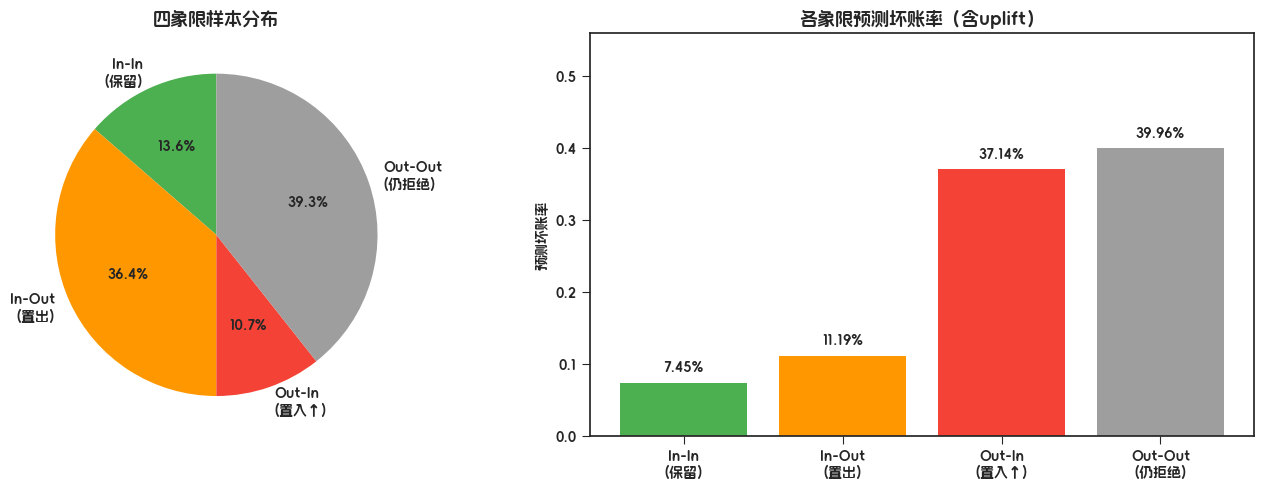


📊 图表已保存: swap_quadrant_overview.png


In [8]:
# swap_summary：四象限样本分布与风险量化
swap_summary = result['swap_summary']

# 格式化展示
display_df = swap_summary.copy()
display_df['样本占比'] = display_df['样本占比'].apply(lambda x: f"{x:.2%}")
display_df['好样本占比'] = display_df['好样本占比'].apply(lambda x: f"{x:.2%}")
display_df['坏样本占比'] = display_df['坏样本占比'].apply(lambda x: f"{x:.2%}")
display_df['坏样本率'] = display_df['坏样本率'].apply(lambda x: f"{x:.4f}")
display_df['LIFT'] = display_df['LIFT'].apply(lambda x: f"{x:.2f}")

print("=== 四象限样本汇总 ===")
display(display_df)

# 可视化四象限分布
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

colors = {'in_in': '#4CAF50', 'in_out': '#FF9800', 'out_in': '#F44336', 'out_out': '#9E9E9E'}
quadrant_names = {'in_in': 'In-In\n(保留)', 'in_out': 'In-Out\n(置出)', 'out_in': 'Out-In\n(置入↑)', 'out_out': 'Out-Out\n(仍拒绝)'}

# 样本数饼图
ax1 = axes[0]
labels = [quadrant_names.get(q, q) for q in swap_summary['象限']]
sizes = swap_summary['样本数'].values
pie_colors = [colors.get(q, '#607D8B') for q in swap_summary['象限']]
wedges, texts, autotexts = ax1.pie(sizes, labels=labels, autopct='%1.1f%%',
                                    colors=pie_colors, startangle=90)
ax1.set_title('四象限样本分布', fontsize=13)

# 坏样本率柱状图
ax2 = axes[1]
bar_colors = [colors.get(q, '#607D8B') for q in swap_summary['象限']]
bars = ax2.bar(swap_summary['象限'].map(quadrant_names), swap_summary['坏样本率'].astype(float), color=bar_colors)
ax2.set_title('各象限预测坏账率（含uplift）', fontsize=13)
ax2.set_ylabel('预测坏账率')
ax2.set_ylim(0, swap_summary['坏样本率'].astype(float).max() * 1.4)
for bar, val in zip(bars, swap_summary['坏样本率'].astype(float)):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
             f'{val:.2%}', ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.savefig('swap_quadrant_overview.png', dpi=150, bbox_inches='tight')
plt.show()
print("\n📊 图表已保存: swap_quadrant_overview.png")

## 7. 结果 2：分步骤通过率与逾期率变化（swap_pipeline）

展示全量样本 → 各象限逐步流转的过程，包含：

- 每步样本数、样本占比(相对)与通过率
- 预测坏账率与 LIFT值
- 规则集命中/未命中/合计分箱
- 调整方向（收紧 / 释放）

**核心列**：`分析流程` | `规则集` | `分箱` | `样本总数` | `样本占比(相对)` | `坏样本率` | `LIFT值` | `通过率` | `通过率(绝对值)` | `通过率(相对值)` | `调整方向`

---
**swap_pipeline** 新增24列结构：`分析流程` → `规则集` → `规则分类` → `规则分类_out` → `分箱` → `样本总数` → `样本占比(相对)` → `好样本数/占比` → `坏样本数/占比` → `坏样本率` → `LIFT值` → `坏帐改善` → `风险拒绝比` → `准确率/精确率/召回率/F1分数` → `通过率(绝对值/相对值)` → `调整方向`

,分析流程,规则集,规则详情,样本总数,样本占比,样本占比(相对),好样本数,好样本占比,坏样本数,坏样本占比,...,通过率,通过率(绝对值),通过率(相对值),通过率变化,调整方向,规则分类_out,指标名称,分箱,金额总数,预估坏金额
0,全部样本,,,338,1.0000,1.0000,79,0.2353,258,0.7647,...,1.0000,1.0000,1.0000,NaN,-,全部样本,,全部样本,1227526.0000,938696.4974
1,OUT-OUT 拒绝样本,基准模型拒绝规则2,,87,0.2574,0.2574,40,0.5063,47,0.8704,...,1.0000,1.0000,1.0000,0.0000,收紧,验证规则,中智小牛分C3 < 550,命中,270950.0000,146375.2874
2,OUT-OUT 拒绝样本,基准模型拒绝规则1,,55,0.1627,0.1627,24,0.3038,31,0.5741,...,1.0000,1.0000,1.0000,0.0000,收紧,验证规则,中智小牛分C3 < 520,命中,150139.0000,84623.8000
3,OUT-OUT 拒绝样本,合计,,133,0.3935,0.3935,31,0.2353,101,0.7647,...,1.0000,1.0000,1.0000,0.0000,收紧,OUT-OUT 拒绝样本,合计,合计,442994.0000,338760.1698
4,OUT-OUT后剩余样本,,,205,0.6065,0.6065,48,0.2353,156,0.7647,...,0.6065,0.6065,0.6065,-0.3935,-,OUT-OUT后剩余样本,,剩余样本,784532.0000,599936.3276
5,IN-OUT 置出样本,高风险拒绝规则2,,43,0.1272,0.2098,31,0.2818,12,0.9231,...,0.6065,0.6065,1.0000,0.0000,释放,验证规则,极光欺诈分6v1 > 0.4 or FPD >= 1,命中,180987.0000,50508.0000
6,IN-OUT 置出样本,高风险拒绝规则1,,29,0.0858,0.1415,17,0.1545,12,0.9231,...,0.6065,0.6065,1.0000,0.0000,释放,验证规则,极光欺诈分6v1 > 0.6 or FPD >= 1,命中,124543.0000,51535.0345
7,IN-OUT 置出样本,合计,,123,0.3639,0.6000,28,0.2353,94,0.7647,...,0.6065,0.6065,1.0000,0.0000,释放,IN-OUT 置出样本,合计,合计,465349.0000,355855.1724
8,IN-OUT后剩余样本,,,82,0.2426,0.4000,19,0.2353,62,0.7647,...,0.2426,0.2426,0.4000,-0.3639,-,IN-OUT后剩余样本,,剩余样本,319183.0000,244081.1552
9,IN-IN 通过样本,合计,,46,0.1361,0.5610,10,0.2353,35,0.7647,...,0.2426,0.2426,1.0000,0.0000,释放,IN-IN 通过样本,合计,合计,190923.0000,145999.9636


=== 分步骤通过率与逾期率变化 ===
列名: ['分析流程', '规则集', '规则详情', '样本总数', '样本占比', '样本占比(相对)', '好样本数', '好样本占比', '坏样本数', '坏样本占比', '坏样本率', 'LIFT值', '坏账改善', '风险拒绝比', '准确率', '精确率', '召回率', 'F1分数', '通过率', '通过率(绝对值)', '通过率(相对值)', '通过率变化', '调整方向', '规则分类_out', '指标名称', '分箱', '金额总数', '预估坏金额']


,分析流程,规则集,分箱,样本总数,样本占比(相对),坏样本率,LIFT值,通过率,通过率(绝对值),通过率(相对值),调整方向
0,全部样本,,全部样本,338,100.00%,0.7647,1.0000,100.00%,1.0000,1.0000,-
1,OUT-OUT 拒绝样本,基准模型拒绝规则2,命中,87,25.74%,0.5402,1.3306,100.00%,1.0000,1.0000,收紧
2,OUT-OUT 拒绝样本,基准模型拒绝规则1,命中,55,16.27%,0.5636,1.3882,100.00%,1.0000,1.0000,收紧
3,OUT-OUT 拒绝样本,合计,合计,133,39.35%,0.7647,1.0000,100.00%,1.0000,1.0000,收紧
4,OUT-OUT后剩余样本,,剩余样本,205,60.65%,0.7647,1.0000,60.65%,0.6065,0.6065,-
5,IN-OUT 置出样本,高风险拒绝规则2,命中,43,20.98%,0.2791,2.6404,60.65%,0.6065,1.0000,释放
6,IN-OUT 置出样本,高风险拒绝规则1,命中,29,14.15%,0.4138,3.9151,60.65%,0.6065,1.0000,释放
7,IN-OUT 置出样本,合计,合计,123,60.00%,0.7647,1.0000,60.65%,0.6065,1.0000,释放
8,IN-OUT后剩余样本,,剩余样本,82,40.00%,0.7647,1.0000,24.26%,0.2426,0.4000,-
9,IN-IN 通过样本,合计,合计,46,56.10%,0.7647,1.0000,24.26%,0.2426,1.0000,释放


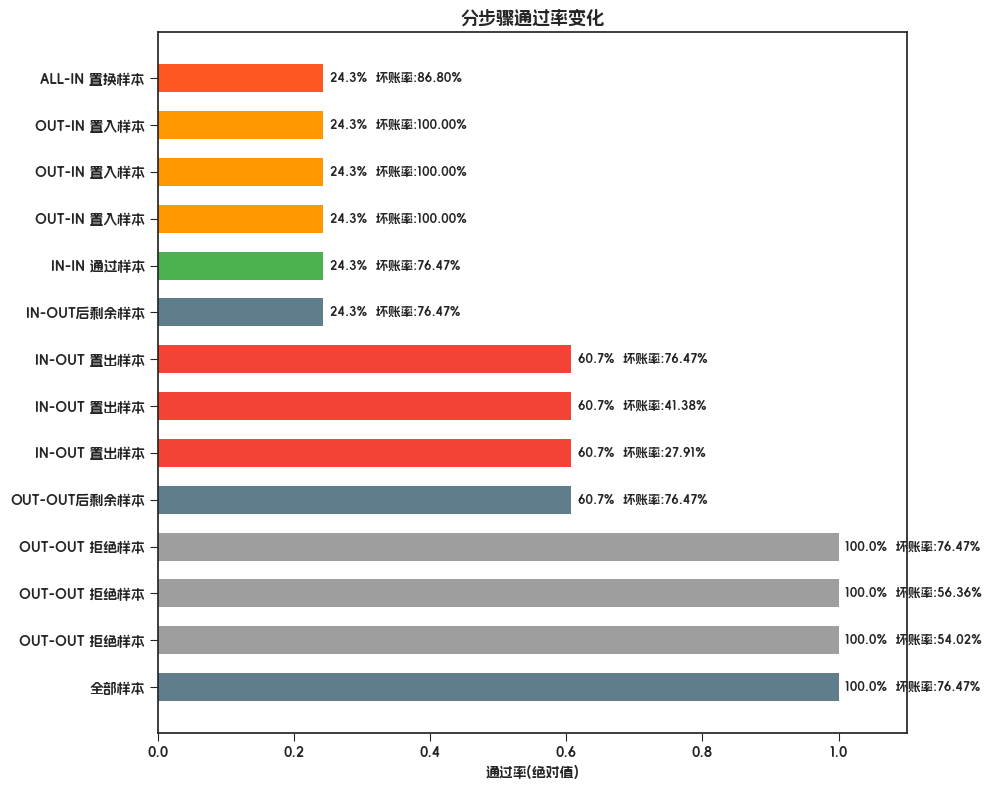


📊 图表已保存: swap_pipeline.png


In [15]:
# swap_pipeline：分步骤通过率变化
swap_pipeline = result['swap_pipeline']

display(swap_pipeline)

display_df2 = swap_pipeline[['分析流程', '规则集', '分箱', '样本总数', '样本占比(相对)', '坏样本率', 'LIFT值', '通过率', '通过率(绝对值)', '通过率(相对值)', '调整方向']].copy()
display_df2['样本占比(相对)'] = display_df2['样本占比(相对)'].apply(lambda x: f"{x:.2%}")
display_df2['坏样本率'] = display_df2['坏样本率'].apply(lambda x: f"{x:.4f}")
display_df2['通过率'] = display_df2['通过率'].apply(lambda x: f"{x:.2%}")

print("=== 分步骤通过率与逾期率变化 ===")
print(f"列名: {list(swap_pipeline.columns)}")
display(display_df2)

# 可视化通过率漏斗
fig, ax = plt.subplots(figsize=(10, 8))

steps = swap_pipeline['分析流程'].values
pass_rates = swap_pipeline['通过率(绝对值)'].astype(float).values
bad_rates = swap_pipeline['坏样本率'].astype(float).values

colors_map = {
    '全部样本': '#607D8B',
    'OUT-OUT 拒绝样本': '#9E9E9E',
    'OUT-OUT后剩余样本': '#607D8B',
    'IN-OUT 置出样本': '#F44336',
    'IN-OUT后剩余样本': '#607D8B',
    'IN-IN 通过样本': '#4CAF50',
    'OUT-IN 置入样本': '#FF9800',
    'ALL-IN 置换样本': '#FF5722',
}
bar_colors = [colors_map.get(s, '#607D8B') for s in steps]

y_pos = range(len(steps))
bars = ax.barh(y_pos, pass_rates, color=bar_colors, height=0.6)
ax.set_yticks(y_pos)
ax.set_yticklabels(steps)
ax.set_xlabel('通过率(绝对值)')
ax.set_title('分步骤通过率变化', fontsize=13)
ax.set_xlim(0, 1.1)
for i, (rate, bad) in enumerate(zip(pass_rates, bad_rates)):
    ax.text(rate + 0.01, i, f'{rate:.1%}  坏账率:{bad:.2%}', va='center', fontsize=9)

plt.tight_layout()
plt.savefig('swap_pipeline.png', dpi=150, bbox_inches='tight')
plt.show()
print("\n📊 图表已保存: swap_pipeline.png")

## 8. 结果 3：置换前后业务增益（swap_result）

对比置换前（仅模型通过）到置换后（模型+规则）的业务指标变化：
- 通过率变化
- 逾期率变化
- 风险上浮系数
- 放款增量（绝对/相对）
- 坏样本变化（绝对/相对）

=== 置换前后业务增益 ===


,指标,变化前,变化后,绝对变化,相对变化
0,通过率变化,13.61%,24.26%,10.65%,78.26%
1,逾期率变化,76.47%,86.80%,10.33%,13.51%
2,风险上浮系数,100.00%,2,100.00%,100.00%
3,放款增量（绝对）,0.00%,"128,260","128,260",67.18%
4,放款增量（相对）,0.00%,67.18%,67.18%,67.18%
5,坏样本变化（绝对）,0.00%,"-159,693","-159,693","-3,472"
6,坏样本变化（相对）,0.00%,"-3,472","-3,472","-3,472"
7,样本集幸存比例,100.00%,100.00%,0.00%,0.00%


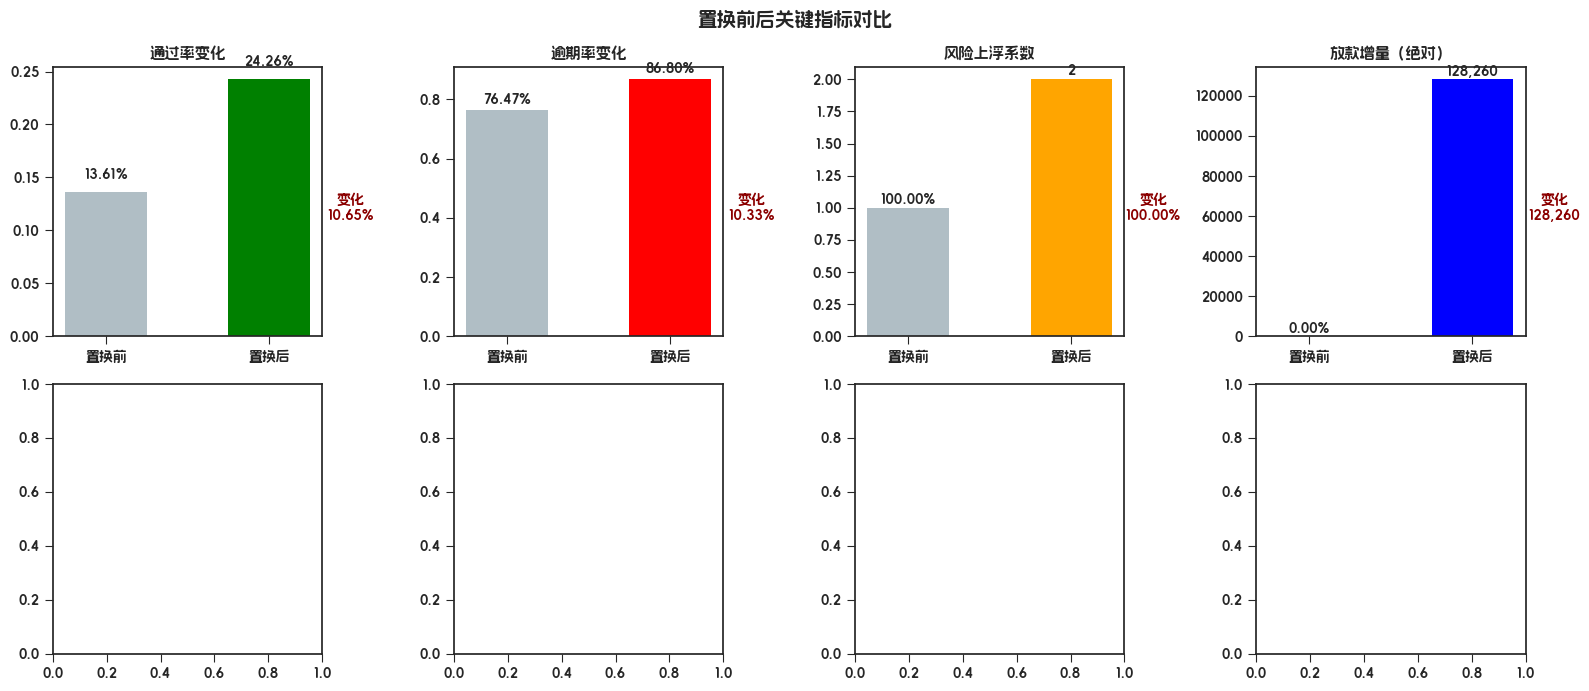


📊 图表已保存: swap_result_metrics.png


In [10]:
# swap_result：业务增益
swap_result = result['swap_result']

# 格式化
def fmt_pct(x):
    try:
        v = float(x)
        if abs(v) < 2:
            return f"{v:.2%}"
        return f"{v:,.0f}"
    except:
        return str(x)

display_df3 = swap_result.copy()
for col in ['变化前', '变化后', '绝对变化', '相对变化']:
    display_df3[col] = display_df3[col].apply(fmt_pct)

print("=== 置换前后业务增益 ===")
display(display_df3)

# 关键指标卡片展示
fig, axes = plt.subplots(2, 4, figsize=(16, 7))
axes = axes.flatten()

metrics_to_plot = [
    ('通过率变化', '通过率变化', 'green'),
    ('逾期率变化', '逾期率变化', 'red'),
    ('风险上浮系数', '风险上浮系数', 'orange'),
    ('放款增量（绝对）', '放款增量（绝对）', 'blue'),
]

for ax, (metric_name, title, color) in zip(axes[:4], metrics_to_plot):
    row = swap_result[swap_result['指标'] == metric_name]
    if len(row) == 0:
        ax.axis('off')
        continue
    before = float(row['变化前'].values[0])
    after = float(row['变化后'].values[0])
    delta = float(row['绝对变化'].values[0])

    x = [0, 1]
    bars = ax.bar(x, [before, after], color=['#B0BEC5', color], width=0.5)
    ax.set_xticks(x)
    ax.set_xticklabels(['置换前', '置换后'])
    ax.set_title(title, fontsize=11)
    for bar, val in zip(bars, [before, after]):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                fmt_pct(val), ha='center', va='bottom', fontsize=10)
    ax.text(1.5, max(before, after) * 0.5, f'变化\n{fmt_pct(delta)}',
            ha='center', va='center', fontsize=10, color='darkred', fontweight='bold')

# 隐藏多余的子图
for i in range(len(metrics_to_plot), 4):
    axes[i].axis('off')

plt.suptitle('置换前后关键指标对比', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('swap_result_metrics.png', dpi=150, bbox_inches='tight')
plt.show()
print("\n📊 图表已保存: swap_result_metrics.png")

## 9. 逆序展示（reverse_order=True）

设置 `reverse_order=True`，从置入效果开始逐步展示，帮助风控人员直观看到每一步规则对风险的影响。流程从"全部样本 → OUT-IN 置入 → IN-IN 通过 → IN-OUT 置出 → OUT-OUT 拒绝 → ALL-IN"倒序展开。

In [11]:
# 逆序展示：先看置入效果，逐步到最终结果
result_rev = rule_swap_analysis(
    df=df_demo,
    score='中智小牛分C3',
    rules_in=rules_in,
    rules_out=rules_out,
    rules_base=rules_base,
    bin_table=bin_table,
    target='target',
    amount='放款金额',
    out_in_uplift=2.0,
    sample_survival_rate=1.0,
    reverse_order=True,
)

swap_pipeline_rev = result_rev['swap_pipeline']
display_df_rev = swap_pipeline_rev[['分析流程', '规则集', '分箱', '样本总数', '样本占比(相对)', '坏样本率', 'LIFT值', '通过率(绝对值)', '调整方向']].copy()
display_df_rev['样本占比(相对)'] = display_df_rev['样本占比(相对)'].apply(lambda x: f"{x:.2%}")
display_df_rev['坏样本率'] = display_df_rev['坏样本率'].apply(lambda x: f"{x:.4f}")
display_df_rev['通过率(绝对值)'] = display_df_rev['通过率(绝对值)'].apply(lambda x: f"{x:.2%}")

print("=== 逆序展示（从置入到最终结果）===")
display(display_df_rev)

=== 逆序展示（从置入到最终结果）===


,分析流程,规则集,分箱,样本总数,样本占比(相对),坏样本率,LIFT值,通过率(绝对值),调整方向
0,全部样本,,全部样本,338,100.00%,0.7647,1.0000,100.00%,-
1,OUT-IN 置入样本,低风险优质客2,命中,36,100.00%,1.0000,1.3077,100.00%,收紧
2,OUT-IN 置入样本,低风险优质客1,命中,29,80.56%,1.0000,1.3077,100.00%,收紧
3,OUT-IN 置入样本,合计,合计,36,100.00%,1.0000,1.3077,100.00%,收紧
4,IN-IN后剩余样本,,剩余样本,82,24.26%,0.7647,1.0000,24.26%,-
5,IN-IN 通过样本,合计,合计,46,56.10%,0.7647,1.0000,24.26%,释放
6,IN-OUT 置出样本,高风险拒绝规则2,命中,43,34.96%,0.2791,2.6404,24.26%,释放
7,IN-OUT 置出样本,高风险拒绝规则1,命中,29,23.58%,0.4138,3.9151,24.26%,释放
8,IN-OUT 置出样本,合计,合计,123,100.00%,0.7647,1.0000,24.26%,释放
9,IN-OUT后剩余样本,,剩余样本,205,250.00%,0.7647,1.0000,60.65%,-


In [12]:
# 多模型加权分析
result_multi = rule_swap_analysis(
    df=df_demo,
    score={'model_a': '中智小牛分C3', 'model_b': '珊瑚92'},
    score_weights={'model_a': 0.6, 'model_b': 0.4},
    rules_in=rules_in,
    rules_out=rules_out,
    rules_base=rules_base,
    bin_table=bin_table,
    target='target',
    amount='放款金额',
    out_in_uplift=2.0,
    sample_survival_rate=1.0,
)

print("=== 多模型加权四象限汇总 ===")
display(result_multi['swap_summary'][['象限', '样本数', '样本占比', '坏样本率', 'LIFT']])

=== 多模型加权四象限汇总 ===


,象限,样本数,样本占比,坏样本率,LIFT
0,in_in,25,0.0740,0.0316,1.0000
1,in_out,57,0.1686,0.0573,1.8145
2,out_in,57,0.1686,0.3331,10.5530
3,out_out,199,0.5888,0.3115,9.8662


## 10. 多模型加权综合评分

支持传入多个评分字段并配置权重，综合预估风险：
- `score_c3`（中智小牛分C3）：权重 0.6
- `score_coral`（珊瑚92）：权重 0.4

In [13]:
# 多模型结果已在上方 cell-23 产生，此处直接使用
print("✅ 多模型结果 result_multi:", {
    'swap_summary': result_multi['swap_summary'].shape,
    'swap_pipeline': result_multi['swap_pipeline'].shape,
    'swap_result': result_multi['swap_result'].shape,
})

✅ 多模型结果 result_multi: {'swap_summary': (4, 11), 'swap_pipeline': (14, 28), 'swap_result': (8, 5)}


## 11. 金额口径分析与置入额度填充

传入 `amount='放款金额'` 后，`swap_summary` 输出中包含 `金额总数` 和 `预估坏金额` 列，从订单和金额两个口径评估风险。

**OUT-IN 客户额度填充**：`out_in_amount_fill` 参数（默认 5000）用于置入样本中无额度的客户；`out_in_amount_col` 指定额度字段名。

In [14]:
# 金额口径验证
swap_amt = result['swap_summary']
amt_cols = [c for c in swap_amt.columns if '金额' in c or '坏金额' in c]
if amt_cols:
    print("=== 金额口径分析 ===")
    display(swap_amt[['象限', '样本数', '金额总数', '预估坏金额']].copy())
else:
    print("swap_summary 当前输出不含金额列（请检查 bin_table 是否包含金额口径）")

=== 金额口径分析 ===


,象限,样本数,金额总数,预估坏金额
0,in_in,46,190923.0000,14229.0000
1,in_out,123,465349.0000,52083.0000
2,out_in,36,128260.0000,47634.0000
3,out_out,133,442994.0000,177010.0000


## 12. 样本幸存比例（sample_survival_rate）

当分析数据仅为全量样本集的子集时，通过率等绝对值需要从幸存比例开始折算。
例如传入 `sample_survival_rate=0.5`，表示本数据集仅为全量样本的 50%。

## 13. 综合汇总

整合三个结果表（swap_summary / swap_pipeline / swap_result）到同一个 DataFrame，列名自动对齐后导出 Excel：

- **swap_pipeline 24列**：`分析流程` | `规则集` | `规则分类` | `规则分类_out` | `分箱` | `样本总数` | `样本占比(相对)` | `好/坏样本数/占比` | `坏样本率` | `LIFT值` | `坏帐改善` | `风险拒绝比` | `准确率/精确率/召回率/F1分数` | `通过率(绝对值/相对值)` | `调整方向`

# 综合汇总：三表合一
summary_all = pd.concat([
    swap_summary.assign(_表='swap_summary'),
    swap_pipeline.assign(_表='swap_pipeline'),
    swap_result.assign(_表='swap_result'),
], ignore_index=True)

print("=== swap_pipeline 列名（24列）===")
print(list(swap_pipeline.columns))

print("\n=== 三表合一预览（核心列）===")
display_cols = ['_表', '分析流程', '规则集', '分箱', '样本总数', '样本占比', '坏样本率', 'LIFT值', '通过率']
display_cols = [c for c in display_cols if c in summary_all.columns]
print(summary_all[display_cols].to_string())

# 导出Excel
summary_all.to_excel('rule_swap_analysis_result.xlsx', sheet_name='全表', index=False)
print("\n📁 完整结果已保存: rule_swap_analysis_result.xlsx")